# Primal Hunt: DQN Ablation

This notebook studies learning in the raw-energy, no-revisit environment in two
stages:

1. controlled one-factor hyperparameter screening and independent validation;
2. a five-seed A-D replay/target-network ablation using the validated settings.

Held-out greedy final energy is the primary metric. Survival is secondary and
may disagree with energy because big-animal outcomes are high-return and risky.

## Quick Start and Script Examples

Run these commands from the project root. Create the environment and install all
runtime, analysis, animation, and notebook dependencies:

```bash
python3 -m venv env
env/bin/python -m pip install -r requirements.txt
```

Verify the environment and agent implementation, then optionally inspect the
random-policy baseline:

```bash
env/bin/python scripts/simulate.py --episodes 10000 --seed 42
```

Run and analyze the controlled hyperparameter study. The analysis selects the
configuration later used by the final experiment:

```bash
env/bin/python scripts/run_hyperparameter_study.py
env/bin/python scripts/analyze_hyperparameter_study.py
```

Train all four A-D configurations on the five final-study seeds and analyze the
saved results:

```bash
env/bin/python scripts/train.py --run-all --seeds 101 202 303 404 505
env/bin/python scripts/analyze_study.py
```

Export standalone policy animations when GIF files are needed outside this
notebook:

```bash
env/bin/python scripts/animate_policies.py \
  --training-seed 303 --evaluation-seed 3030303
```

## 1. Environment and Observation Design

### Game mechanics

The hunter starts at home in the centre of a fixed $5\times5$ map with zero
energy and has exactly six moves. The map contains four vegetation cells, three
small-animal cells, two big-animal cells, four obstacles, home, and empty cells.
Movement is deterministic, but food, effort, and injury at the destination are
stochastic. A visited destination cannot be entered again, so every episode is a
short self-avoiding path through the map.

### MDP definition

The finite-horizon MDP is $(\mathcal S,\mathcal A,P,R,H)$:

- **State/observation (52 features):** current position one-hot (25), visited
  mask (25), remaining steps divided by 6, and cumulative energy divided by
  100. The raw energy is not clipped, so scaling does not merge distinct states.
- **Actions:** left, up, right, and down. Out-of-bounds and previously visited
  destinations are masked during exploration, greedy action selection, and the
  Bellman maximization.
- **Transition:** a valid action deterministically changes position and marks
  the destination visited. The destination cell then samples food $F$, effort
  $C$, and injury $I$. An invalid action would leave the agent in place, but
  valid-action masking prevents it under the implemented policies.
- **Reward and energy:** $r_t=\Delta E_t=F_t-(C_t+I_t)$ and
  $E_{t+1}=E_t+\Delta E_t$.
- **Horizon:** $H=6$; termination occurs after the sixth action. There is no
  additional terminal reward or punishment and no environment truncation.
- **Objective:** maximize $\mathbb E[\sum_{t=0}^{5}r_t]$. Since $E_0=0$, this
  equals expected final energy. Gamma is therefore 1.
- **Secondary survival metric:** survival is recorded when final energy is
  strictly greater than zero. It is not the optimized reward.

The visited mask is essential: without it, two histories at the same position
and energy could permit different next actions, making the observation
non-Markov.

### Cell outcome model

All positive magnitudes use non-negative truncated normal distributions with
standard deviation 1:

| Destination | Food | Effort | Injury |
|---|---|---|---|
| Vegetation | 95% chance, mean 5 | always, mean 3 | 5% chance, mean 3 |
| Small animal | 70% chance, mean 9 | always, mean 5 | 10% chance, mean 6 |
| Big animal | 45% chance, mean 60 | always, mean 15 | 30% chance, mean 20 |
| Obstacle | none | always, mean 5 | 25% chance, mean 20 |
| Empty/home | none | none | none |

This design deliberately creates a risk-return choice. Big animals offer high
expected energy but frequent negative outcomes; vegetation is modest and safer;
obstacles have negative expected value. Consequently, maximizing expected
energy is not equivalent to maximizing survival probability.

## 2. Reproducible Analysis Setup

The cells below regenerate tables and plots from saved results. Hyperparameter
development seeds (`11,22,33`), validation seeds (`44,55,66`), and final-study
seeds (`101,202,303,404,505`) are disjoint.

In [12]:
from pathlib import Path
import importlib
import json
import sys
import matplotlib.pyplot as plt
from IPython.display import HTML, display

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "scripts" / "analyze_study.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate the Primal Hunt project root.")

ROOT = find_project_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import scripts.analyze_hyperparameter_study as hyper_analysis
import scripts.analyze_study as study_analysis
import scripts.animate_policies as policy_animation
importlib.reload(hyper_analysis)
importlib.reload(study_analysis)
importlib.reload(policy_animation)

RESULTS = ROOT / "results"
HYPER = RESULTS / "hyperparameter_study"
screen_candidates, screen_seed, screen_evaluations = hyper_analysis.load_stage(
    HYPER / "screening"
)
validation_candidates, validation_seed, validation_evaluations = hyper_analysis.load_stage(
    HYPER / "validation"
)
hyper_tables = {
    "screening_quality": hyper_analysis.quality_table(screen_candidates, screen_seed),
    "controlled_effects": hyper_analysis.controlled_effects(screen_candidates, screen_seed),
    "validation_quality": hyper_analysis.quality_table(validation_candidates, validation_seed),
}

episodes, per_seed, evaluations = study_analysis.load_study_data(RESULTS)
energy_changes = study_analysis.sample_cell_energy_changes(20_000)
study_tables = {
    "validation": study_analysis.validate_study_data(episodes, per_seed, evaluations),
    "energy_summary": study_analysis.energy_summary(energy_changes),
    "policy_quality": study_analysis.policy_quality(per_seed),
    "paired_effects": study_analysis.paired_effects(per_seed),
    "stability": study_analysis.stability_summary(episodes, per_seed),
    "periodic_evaluation": study_analysis.periodic_evaluation_summary(evaluations),
}
selected = json.loads((HYPER / "selected_config.json").read_text())

## 3. Map and Stochastic Energy Structure

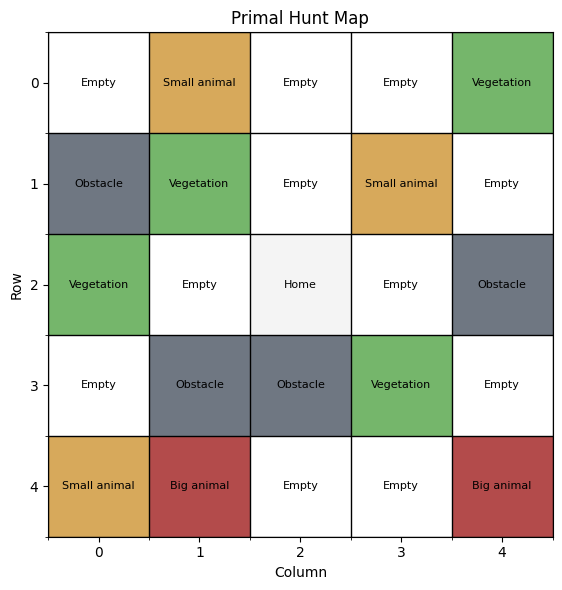

,cell_type,mean_energy_delta,energy_delta_std,probability_negative,mean_food,mean_effort,mean_injury
0,Big animal,5.996,31.127,0.548,27.091,15.018,6.077
1,Obstacle,-9.947,8.707,1.000,0.000,4.987,4.960
2,Small animal,0.717,4.664,0.363,6.304,4.996,0.591
3,Vegetation,1.629,1.883,0.151,4.767,2.998,0.140


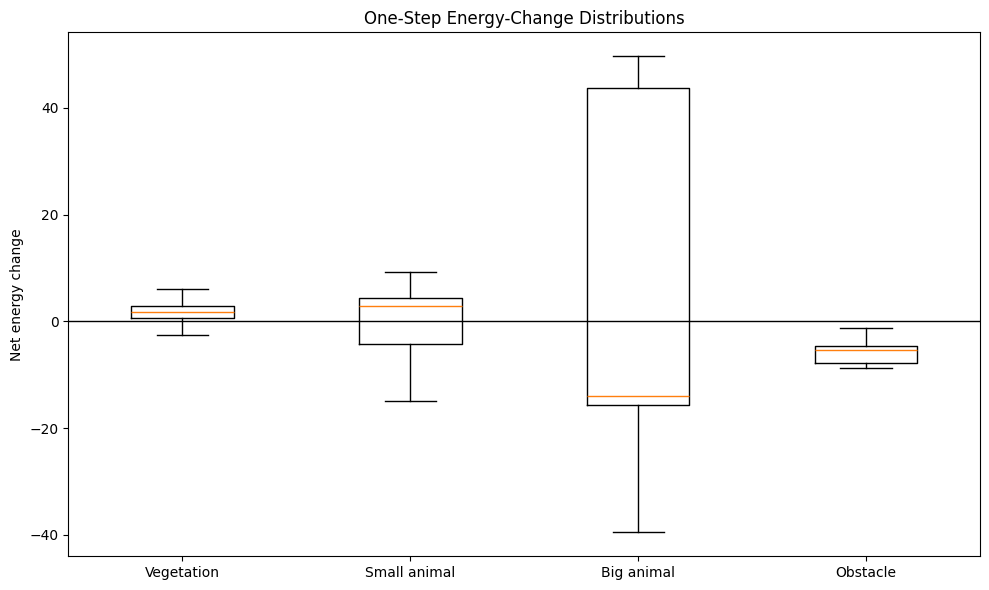

In [13]:
fig = study_analysis.plot_map()
display(fig)
plt.close(fig)
display(study_tables["energy_summary"].round(3))
fig = study_analysis.plot_energy_change_distributions(energy_changes)
display(fig)
plt.close(fig)

The Monte Carlo cell summary confirms the intended ordering. Vegetation has
mean one-step energy about `+1.63` and is negative about 15% of the time. Small
animals average only `+0.72` and are negative about 36% of the time. Big animals
average about `+6.00`, but their standard deviation is about 31.13 and 54.8% of
individual visits lose energy. Obstacles average `-9.95` and are negative in
every sampled visit.

Thus a policy can raise expected energy by visiting big animals even while its
chance of ending above zero falls. This mechanism later explains why replay
improves the primary energy objective but produces lower survival than the
safer no-replay policies.

## 4. Controlled Hyperparameter Study

Starting from `lr=0.001`, batch `128`, target interval `50`, epsilon decay
`30000`, warmup `1000`, and hidden width `64`, one factor was changed at a time:

- learning rate: `3e-4`, `1e-3`, `3e-3`;
- batch size: `64`, `128`, `256`;
- target interval: `25`, `50`, `100`;
- epsilon decay: `20000`, `30000`, `40000`.

Nine unique settings were trained on three development seeds for 5,000 episodes.
Greedy policy quality was evaluated every 250 episodes using 100 stochastic
episodes and finally using 500 episodes. Development results were used only to
construct a candidate; they were not reused as evidence for final selection.

,run_id,lr,batch_size,target_update,epsilon_decay,warmup_steps,hidden_dim,varying_parameter,value,seeds,eval_mean_final_energy,between_seed_final_energy_std,eval_survival_rate,between_seed_survival_std
0,H_TARGET_LOW,0.0010,128,25,30000,1000,64,target_update,25.0000,3,9.4352,0.0668,0.4713,0.0031
1,H_LR_LOW,0.0003,128,50,30000,1000,64,lr,0.0003,3,9.4079,0.6014,0.4673,0.0064
2,H_BATCH_HIGH,0.0010,256,50,30000,1000,64,batch_size,256.0000,3,8.9677,0.2363,0.4673,0.0064
3,H_LR_HIGH,0.0030,128,50,30000,1000,64,lr,0.0030,3,8.6526,1.0389,0.4573,0.0272
4,H_TARGET_HIGH,0.0010,128,100,30000,1000,64,target_update,100.0000,3,8.4571,0.8994,0.4527,0.0239
5,H_BATCH_LOW,0.0010,64,50,30000,1000,64,batch_size,64.0000,3,8.3976,1.7344,0.4500,0.0312
6,H00,0.0010,128,50,30000,1000,64,baseline,0.0000,3,8.2373,1.6034,0.4507,0.0318
7,H_EPSILON_HIGH,0.0010,128,50,40000,1000,64,epsilon_decay,40000.0000,3,7.0011,0.5451,0.4213,0.0064
8,H_EPSILON_LOW,0.0010,128,50,20000,1000,64,epsilon_decay,20000.0000,3,4.4919,7.9653,0.4527,0.0318


,parameter,run_id,parameter_value,seeds,mean_final_energy,final_energy_std,mean_survival
0,lr,H00,0.0010,3,8.2373,1.6034,0.4507
1,lr,H_LR_HIGH,0.0030,3,8.6526,1.0389,0.4573
2,lr,H_LR_LOW,0.0003,3,9.4079,0.6014,0.4673
3,batch_size,H00,128.0000,3,8.2373,1.6034,0.4507
4,batch_size,H_BATCH_HIGH,256.0000,3,8.9677,0.2363,0.4673
5,batch_size,H_BATCH_LOW,64.0000,3,8.3976,1.7344,0.4500
6,target_update,H00,50.0000,3,8.2373,1.6034,0.4507
7,target_update,H_TARGET_HIGH,100.0000,3,8.4571,0.8994,0.4527
8,target_update,H_TARGET_LOW,25.0000,3,9.4352,0.0668,0.4713
9,epsilon_decay,H00,30000.0000,3,8.2373,1.6034,0.4507


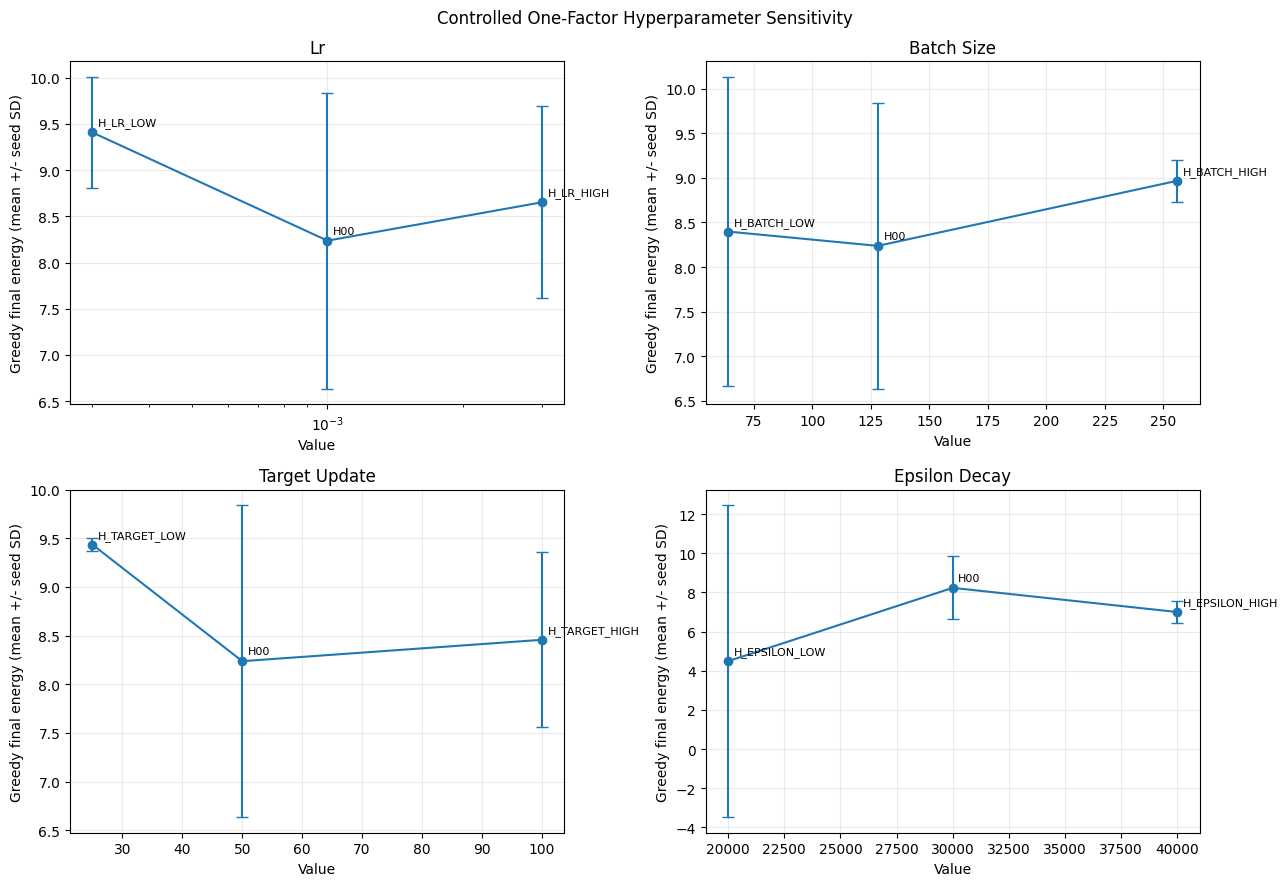

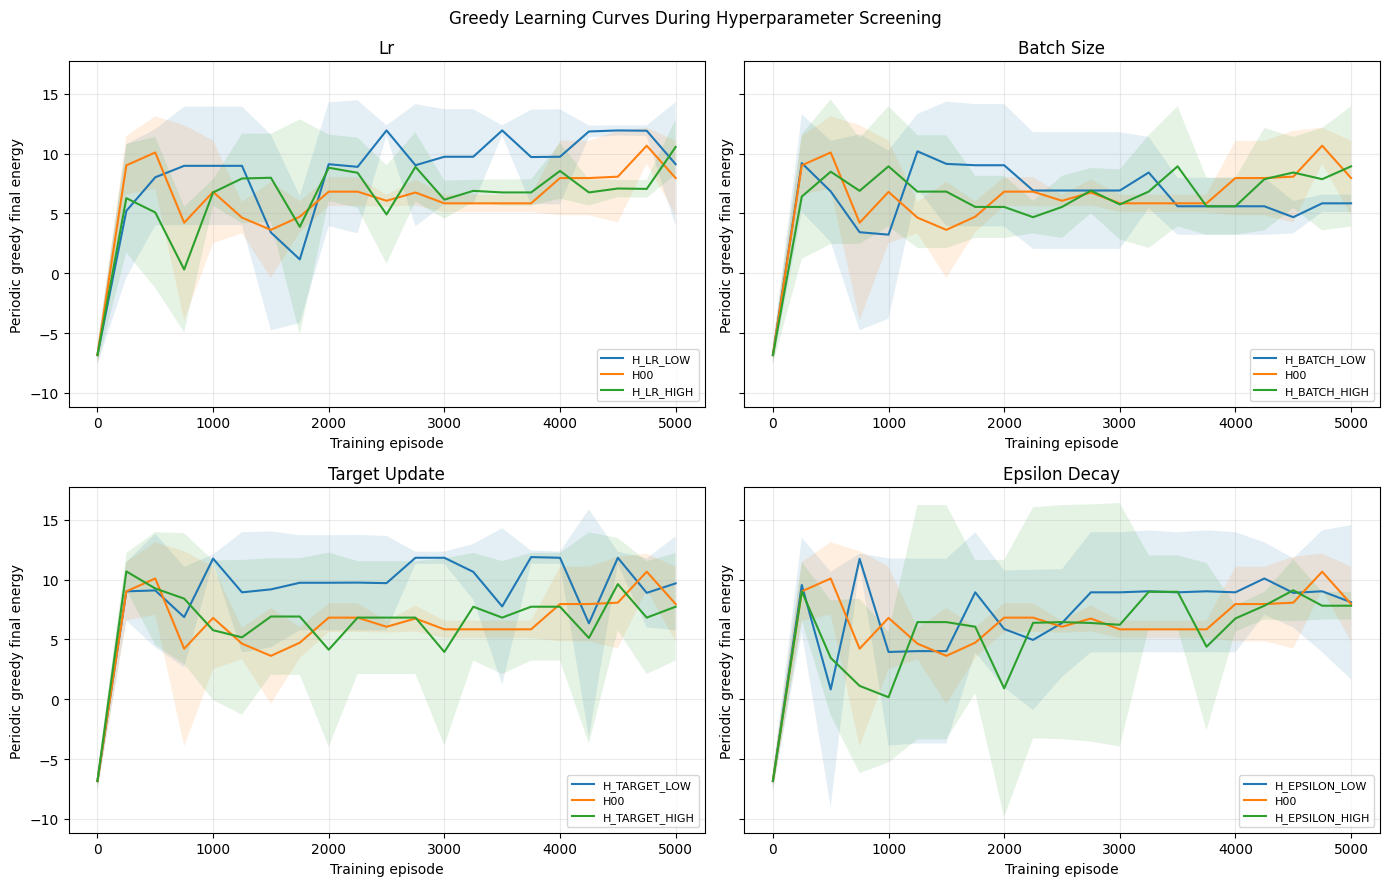

In [14]:
display(hyper_tables["screening_quality"].round(4))
display(hyper_tables["controlled_effects"].round(4))
fig = hyper_analysis.plot_controlled_effects(hyper_tables["controlled_effects"])
display(fig)
plt.close(fig)
fig = hyper_analysis.plot_periodic_factor_curves(screen_evaluations)
display(fig)
plt.close(fig)

The one-factor screen suggested `lr=3e-4` (energy 9.408), batch `256`
(8.968), and target interval `25` (9.435) individually. The very small observed
seed SD for target interval 25 (`0.067`) is development evidence, not a guarantee.
Epsilon decay was especially sensitive: 20,000 steps produced mean energy 4.492
with SD 7.965, indicating strong seed dependence; 30,000 was better than both
20,000 and 40,000 in this screen.

The individually preferred levels were combined and compared with the baseline
on three new validation seeds. This stage tests interactions rather than
assuming that individually favorable changes combine additively.

,run_id,lr,batch_size,target_update,epsilon_decay,warmup_steps,hidden_dim,varying_parameter,value,seeds,eval_mean_final_energy,between_seed_final_energy_std,eval_survival_rate,between_seed_survival_std
0,V0,0.0010,128,50,30000,1000,64,validation_baseline,0.0,3,9.2846,1.5389,0.4580,0.0295
1,V1,0.0003,256,25,30000,1000,64,combined,0.0,3,9.1646,1.1398,0.4553,0.0242


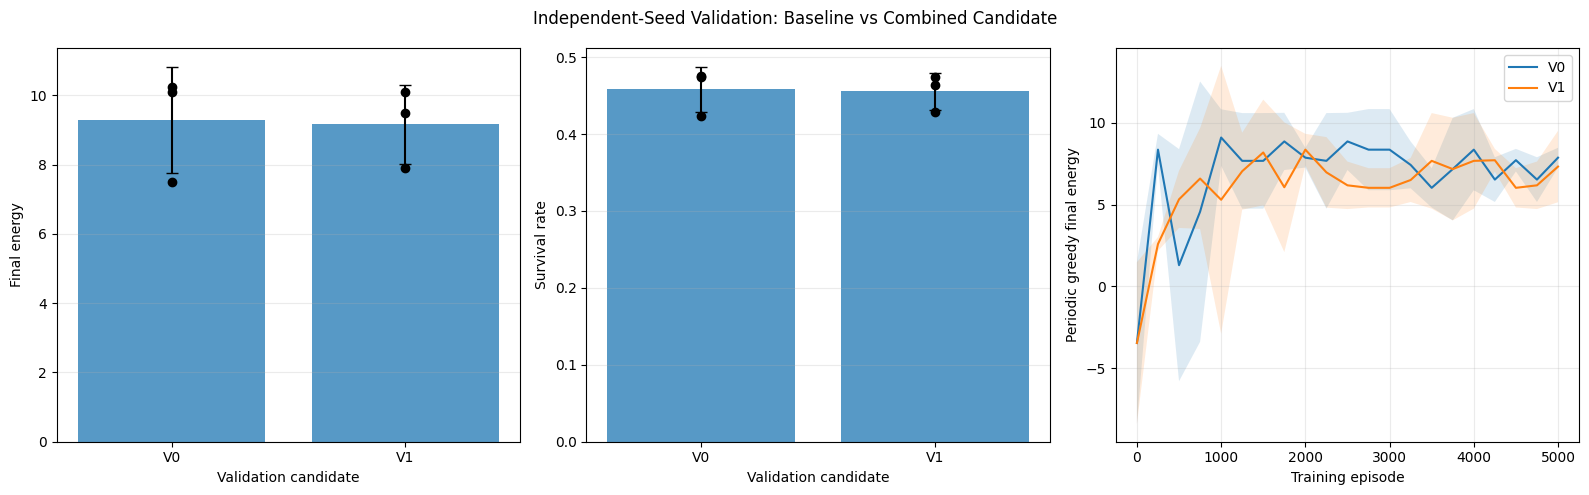

{'run_id': 'V0',
 'lr': 0.001,
 'batch_size': 128,
 'target_update': 50,
 'warmup_steps': 1000,
 'epsilon_decay': 30000,
 'hidden_dim': 64,
 'gamma': 1.0,
 'buffer_size': 100000,
 'train_freq': 1,
 'validation_mean_final_energy': 9.284578274184238,
 'validation_final_energy_std': 1.5388592907811625}

In [15]:
display(hyper_tables["validation_quality"].round(4))
fig = hyper_analysis.plot_validation(validation_seed, validation_evaluations)
display(fig)
plt.close(fig)
display(selected)

The combined candidate did not validate: mean final energy was 9.165 versus
9.285 for the baseline, while survival was 0.455 versus 0.458. Their seed-level
error bars and learning curves overlap substantially. The baseline was therefore
retained: learning rate 0.001, batch 128, target interval 50, epsilon decay
30,000, warmup 1,000, and hidden width 64. This avoided converting
development-seed fluctuations into a claimed improvement.

## 5. Five-Seed A-D Study

| ID | Replay | Target network | Interpretation |
|---|---:|---:|---|
| A | Yes | Yes | Full DQN |
| B | Yes | No | Moving online-network target |
| C | No | Yes | Correlated online samples, frozen target |
| D | No | No | Correlated samples and moving target |

All applicable hyperparameters, training episodes, evaluation schedules, and
paired seeds were held constant. Final evaluation uses 500 stochastic episodes
per trained policy.

### Shared neural Q-learning implementation

- The Q-network is an MLP `52 -> 64 -> 64 -> 4` with ReLU hidden units and one
  output per action.
- Adam minimizes mean squared TD error once per environment step. Gradients are
  clipped to norm 5; the logged gradient norm is measured before clipping.
- Epsilon decreases linearly from 1.0 to 0.05 over 30,000 environment steps.
  Because 5,000 six-step episodes also contain 30,000 steps, exploration reaches
  its floor at the end of training.
- Replay configurations store up to 100,000 transitions, wait for 1,000
  transitions, and sample uniform minibatches of 128. No-replay configurations
  update from the latest transition with effective batch size 1.
- Target configurations start with an exact policy-network copy and hard-sync
  it every 50 environment steps. Without a target network, the policy network
  supplies both prediction and bootstrap target.
- Terminal transitions suppress bootstrapping. The stored next-state valid mask
  is applied before every target maximum, so invalid/revisited actions never
  inflate the Bellman target.

### Experimental controls and recorded evidence

Each A-D configuration used the same five training seeds, 5,000 episodes, and
held-out evaluation-seed construction. Greedy evaluation does not consume the
training RNG. We saved per-episode reward/survival/loss/diagnostics, 21 periodic
greedy checkpoints per seed (episode 0 and every 250 episodes), final
500-episode evaluations, and all final policy checkpoints.

In [16]:
display(study_tables["validation"])

,check,value
0,Configurations,"A, B, C, D"
1,Seeds per configuration,5
2,Episodes per seed,5000
3,Duplicate episode rows,0
4,Non-finite recorded losses,0
5,Final epsilon (mean),0.05
6,Periodic evaluations per seed,21


## 6. Greedy Learning Curves

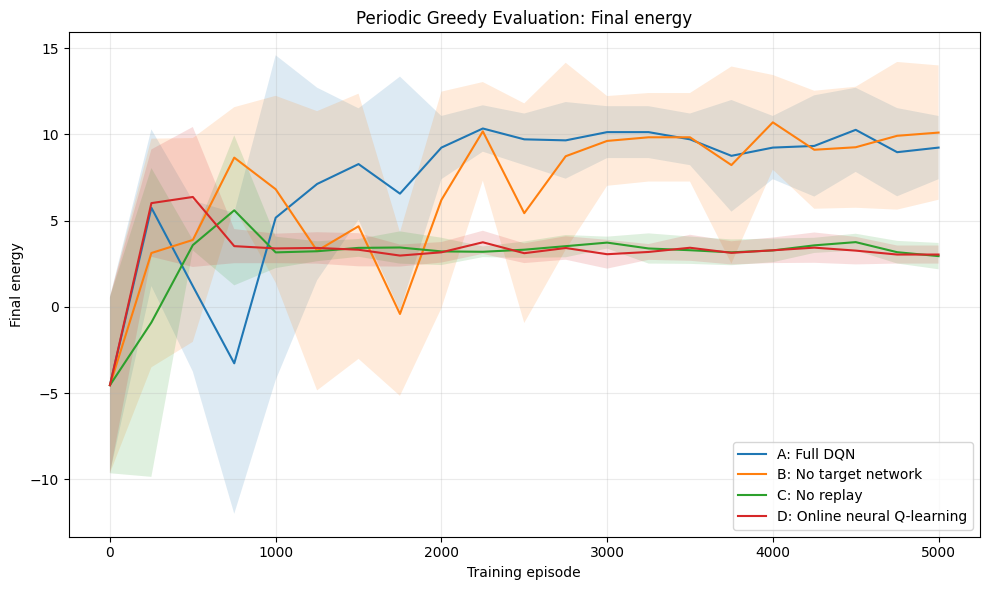

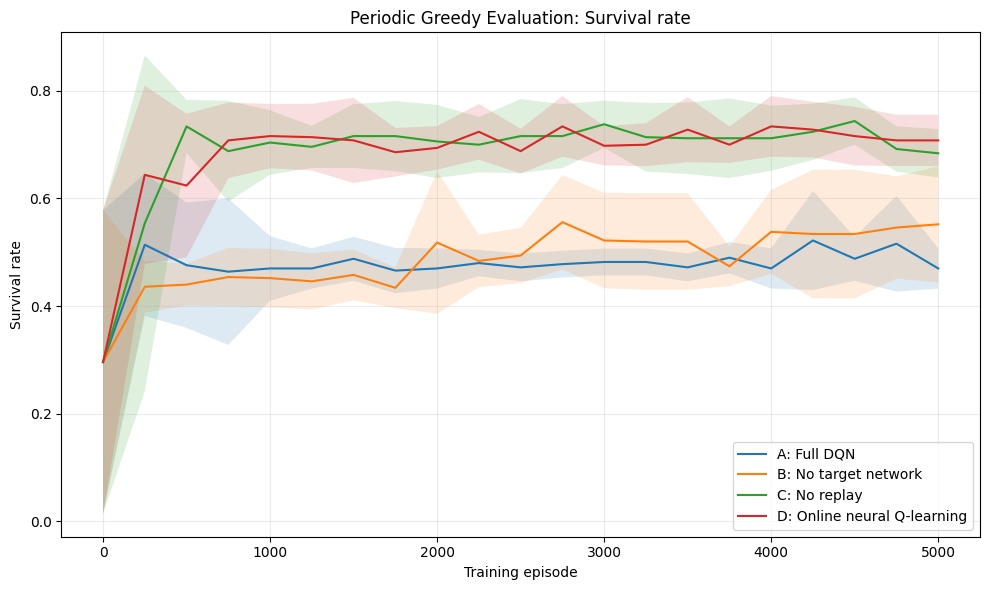

,run_id,checkpoint_episode,mean_final_energy,between_seed_energy_std,mean_survival,between_seed_survival_std
0,A,5000,9.2358,1.8330,0.470,0.0374
1,B,5000,10.1061,3.8944,0.552,0.1080
2,C,5000,2.9435,0.7642,0.684,0.0451
3,D,5000,3.0350,0.5238,0.708,0.0476


In [17]:
fig = study_analysis.plot_periodic_evaluation(
    evaluations, "mean_final_energy", "Final energy"
)
display(fig)
plt.close(fig)
fig = study_analysis.plot_periodic_evaluation(
    evaluations, "survival_rate", "Survival rate"
)
display(fig)
plt.close(fig)
display(study_tables["periodic_evaluation"].round(4))

Periodic greedy evaluation separates learned policy quality from epsilon-driven
training behavior. The checkpoint estimates use 100 episodes and are noisier
than the independent final 500-episode evaluation, so final policy ranking is
based on the latter.

All configurations begin near `-4.5` energy. C and D improve rapidly and settle
near energy 3 by roughly episode 750; their survival stabilizes around
0.68-0.72. A and B are much less stable across early checkpoints, but after
about 2,000 episodes they separate upward in energy and eventually reach roughly
9-10. Their survival remains lower, approximately 0.45-0.55. Replay therefore
changes the learned risk profile: it supports risky high-expected-energy paths,
while no-replay learning converges to safer low-energy behavior.

B retains the widest checkpoint seed band. Removing the target network in the
replay setting therefore appears less reproducible, although the final paired
target contrast remains statistically unresolved. The final checkpoint table
can differ from the final-policy table because it uses 100 episodes and a
different held-out seed block; the 500-episode result is the primary estimate.

### Exploratory Training Behavior

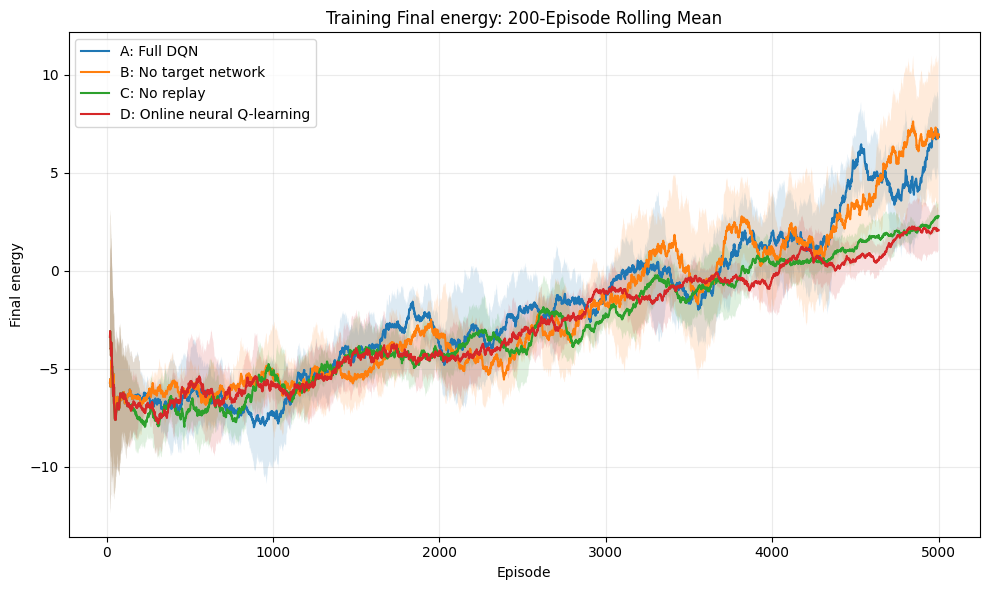

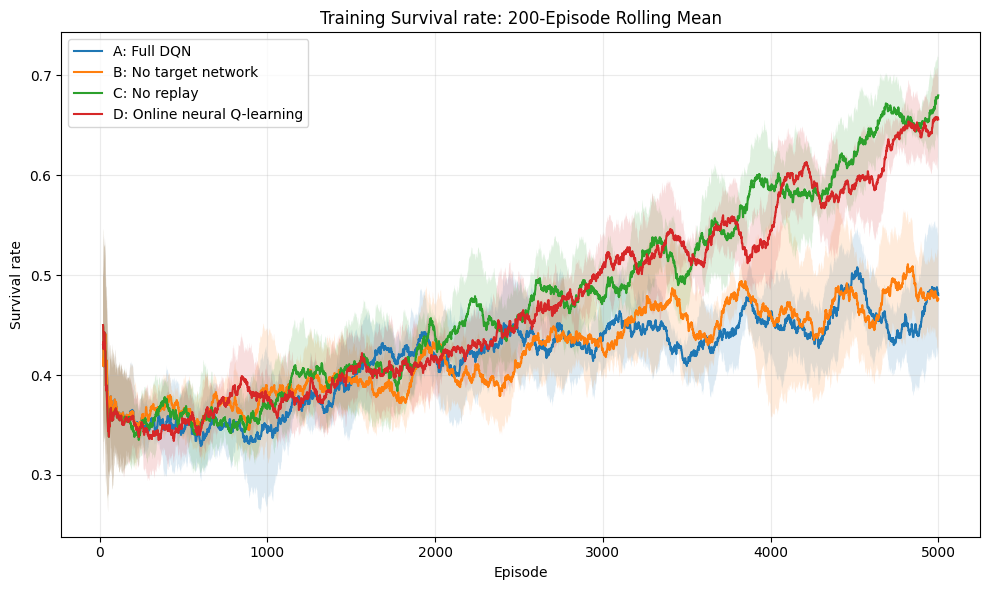

In [18]:
fig = study_analysis.plot_training_metric(
    episodes, "final_energy", "Final energy", 200
)
display(fig)
plt.close(fig)
fig = study_analysis.plot_training_metric(
    episodes, "survived", "Survival rate", 200
)
display(fig)
plt.close(fig)

All methods improve from about -7 rolling energy. A and B
finish around 6-7 with larger seed bands, whereas C and D finish around 2-3.

## 7. Empirical Stability Diagnostics

,run_id,late_objective_return,late_final_energy,late_final_energy_variability,late_train_survival,late_td_loss,late_td_loss_variability,late_gradient_norm,late_max_gradient_norm,late_weight_norm,late_mean_abs_q,late_max_abs_q,late_target_distance,evaluation_final_energy_variability
0,A,5.1941,5.1941,29.7859,0.4576,94.1959,11.6929,45.3258,112.3987,29.8094,5.5414,36.0182,0.3440,31.9397
1,B,6.2022,6.2022,29.0496,0.4804,99.3804,12.1134,42.6647,105.6251,29.9501,4.9714,32.2597,NaN,26.5251
2,C,2.2849,2.2849,9.3494,0.6648,14.8272,38.7136,31.0053,1408.6622,16.5769,4.5386,10.9927,0.2216,6.8826
3,D,1.8192,1.8192,9.2717,0.6468,14.1126,33.7651,30.4423,1195.2586,16.7299,4.4607,11.0334,NaN,6.9010


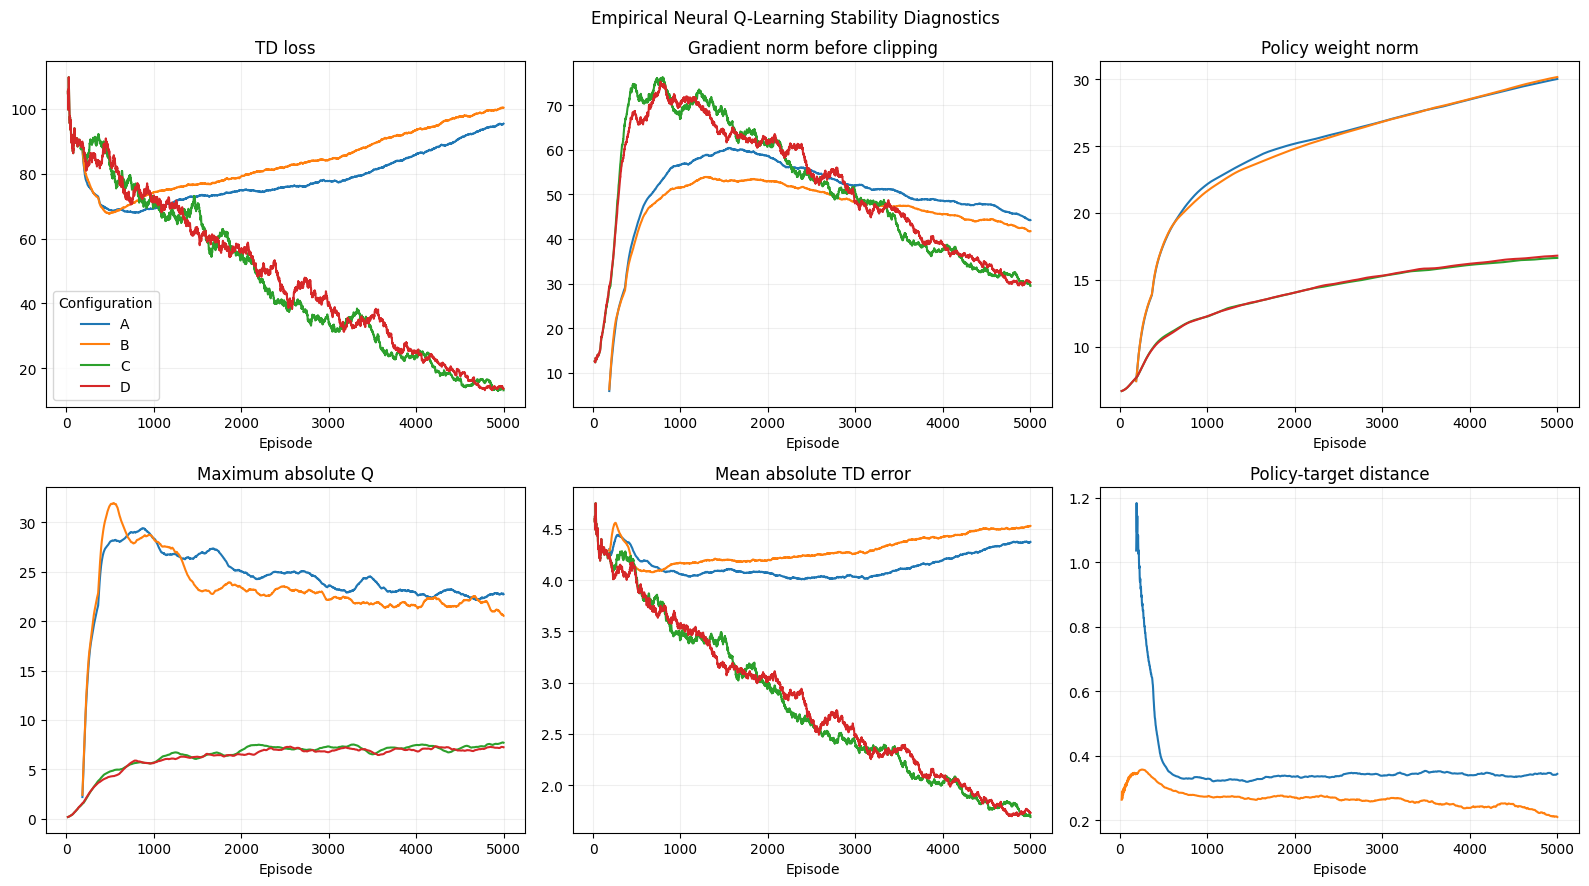

In [19]:
display(study_tables["stability"].round(4))
fig = study_analysis.plot_stability_diagnostics(episodes, 200)
display(fig)
plt.close(fig)



- **TD loss:** A/B fall initially but then rise gradually to late means 94.2 and
  99.4. C/D decline to 14.8 and 14.1. The larger replay loss is consistent with
  minibatches containing rare big-animal rewards and policies whose evaluation
  energy SD is 26-32, versus about 6.9 for C/D. It is not, by itself, evidence
  that replay diverged.
- **Gradient norm before clipping:** rolling means peak around 70-75 and then
  decline. Late means are 45.3 (A), 42.7 (B), 31.0 (C), and 30.4 (D). However,
  C/D have rare late maxima around 1,409 and 1,195, far above A/B maxima around
  112 and 106. Gradient clipping to 5 prevents those raw spikes from becoming
  optimizer steps of the same magnitude. The 200-episode rolling plot hides
  individual spikes.
- **Weight norm:** A/B grow smoothly to about 30; C/D grow to about 16.6-16.7.
  None shows abrupt or unbounded growth within 5,000 episodes.
- **Q magnitude:** A/B peak near 29-32 and end near 21-23; C/D settle near 7.
  These finite scales track the higher-return policies learned with replay and
  do not show Q-value explosion.
- **Absolute TD error:** A/B remain near 4.0-4.5, whereas C/D decline toward
  1.7. Again, the lower no-replay error accompanies an easier, lower-variance
  policy and does not imply better final energy.
- **Policy-target distance:** only A and C use target networks. The raw distance
  resets to zero at each hard sync; its rolling mean settles near 0.34 for A and
  0.22 for C. A's larger gap is consistent with its larger, noisier updates.

Overall, there is no observed parameter or Q-value explosion. Replay raises
the scale and variance of the learning problem while improving the objective;
no replay produces smaller average errors but rare extreme gradients.

## 8. Final Greedy Policy Quality

,run_id,seeds,eval_mean_final_energy,between_seed_final_energy_std,mean_within_policy_final_energy_std,eval_survival_rate,between_seed_survival_std
0,A,5,8.6945,0.6517,31.9397,0.4632,0.0086
1,B,5,7.4537,2.0566,26.5251,0.5076,0.1257
2,C,5,2.6621,0.3163,6.8826,0.6708,0.0114
3,D,5,2.6122,0.1117,6.9010,0.6636,0.0132


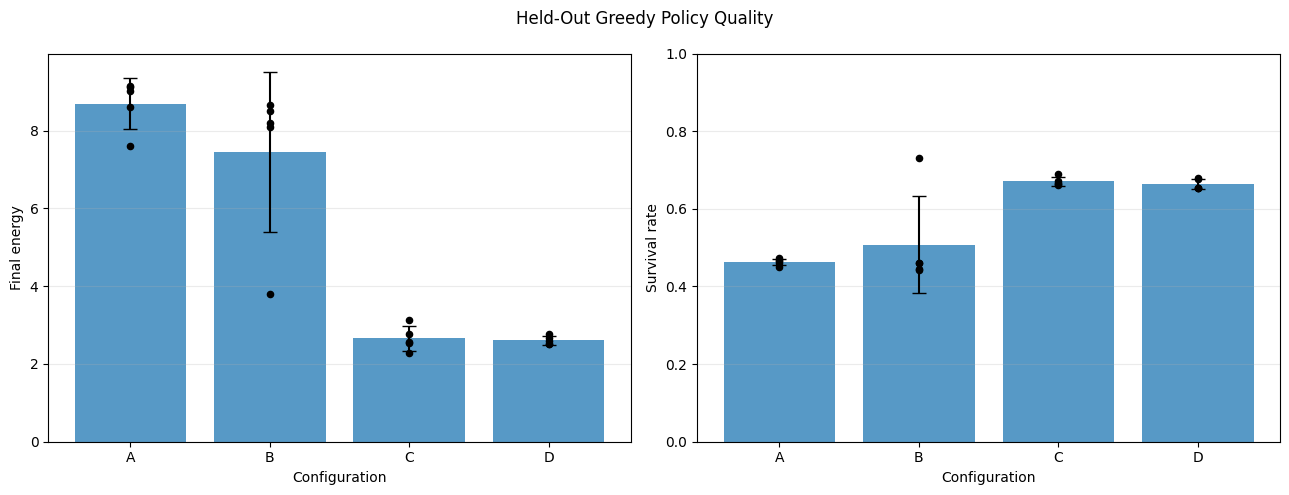

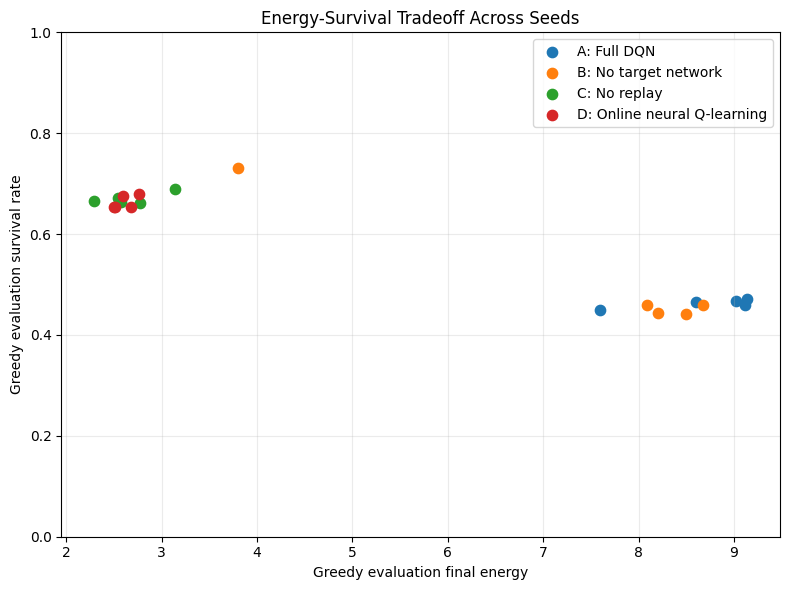

In [20]:
display(study_tables["policy_quality"].round(4))
fig = study_analysis.plot_policy_quality(per_seed)
display(fig)
plt.close(fig)
fig = study_analysis.plot_energy_survival_tradeoff(per_seed)
display(fig)
plt.close(fig)

A has the highest mean final energy, 8.695, and the smallest between-seed energy
SD among replay methods (0.652). B reaches 7.454 but has SD 2.057 and one visibly
poor seed, supporting the qualitative observation that replay without a fixed
target is less reproducible. C and D are tightly clustered near energy 2.66 and
2.61.

Survival reverses the ranking: C is highest at 0.671, D is 0.664, B is 0.508,
and A is 0.463. The tradeoff plot forms two distinct groups: A/B occupy the
high-energy, low-survival region, while C/D occupy the low-energy, high-survival
region. This is the expected consequence of raw-energy reward: replay helps retain rare high-value animal transitions and supports
riskier policies.

## 9. Paired Replay and Target Effects

In [21]:
display(study_tables["paired_effects"].round(4))

,metric,effect,contrast,seeds,mean_paired_difference,ci_95_low,ci_95_high,p_value
0,eval_mean_final_energy,Target effect with replay,A - B,5,1.2408,-1.6080,4.0895,0.2931
1,eval_mean_final_energy,Target effect without replay,C - D,5,0.0499,-0.2400,0.3398,0.6577
2,eval_mean_final_energy,Replay effect with target,A - C,5,6.0324,5.2311,6.8338,0.0000
3,eval_mean_final_energy,Replay effect without target,B - D,5,4.8415,2.3061,7.3770,0.0061
4,eval_survival_rate,Target effect with replay,A - B,5,-0.0444,-0.1978,0.1090,0.4668
5,eval_survival_rate,Target effect without replay,C - D,5,0.0072,-0.0081,0.0225,0.2606
6,eval_survival_rate,Replay effect with target,A - C,5,-0.2076,-0.2288,-0.1864,0.0000
7,eval_survival_rate,Replay effect without target,B - D,5,-0.1560,-0.3048,-0.0072,0.0437


- Replay effect with target, A-C: +6.032 energy, 95% CI [5.231, 6.834].
- Replay effect without target, B-D: +4.842 energy, 95% CI [2.306, 7.377].
- Target effects A-B and C-D have intervals crossing zero.
- Replay lowers survival in both target conditions because the optimized energy
  policy accepts more risk.

Thus replay has clear evidence for the stated energy objective. Five seeds do
not resolve a target-network advantage and the remains uncertain.

## 10. Synthesis: Curves, Final Policies, and Theory

The learning curves and final evaluations support different parts of DQN theory
with different strengths:

### A: full DQN

A is noisy early, but its greedy energy rises clearly after about 2,000 episodes
and it finishes with the best final mean energy (8.695) and relatively small
between-seed SD (0.652). Replay breaks the short-range correlation between
successive six-step trajectories and repeatedly exposes the network to rare
big-animal transitions. The target network holds bootstrap values fixed between
50-step synchronizations. A's bounded Q and weight curves and moderate
policy-target distance are consistent with these mechanisms controlling the two
standard neural Q-learning instabilities.

### B: replay without a target network

B also learns a high-energy policy, showing that replay is the dominant useful
component in this task. However, its checkpoint curve oscillates more and its
final between-seed energy SD (2.057) is more than three times A's. This pattern
is consistent with the **moving-target problem**: the policy network changes the
prediction and the bootstrap label after every optimizer update. It's still not statistical
proof that the missing target caused the variation, because A-B's paired energy
CI crosses zero and stochastic big-animal outcomes also amplify variability.

### C: target network without replay

C improves rapidly to a stable, safer policy, but plateaus near final energy
2.66. Its target network limits bootstrap drift, while updates still use the
latest temporally correlated transition. The low TD error and small Q scale do
not demonstrate superior optimization; they reflect a lower-variance policy
that rarely pursues the largest rewards. Rare pre-clipping gradient spikes are
consistent with individual recent outcomes having disproportionate influence
when no replay minibatch averages them.

### D: neither replay nor target network

D combines correlated online samples with a moving bootstrap target, the least
protected form of neural Q-learning. Theory predicts the greatest risk of
instability, but D does **not** numerically diverge here. Its curves closely track
C and its final policy is similarly safe and low-energy. The short horizon,
dense reward, normalized inputs, small network, Adam, action masking, and
gradient clipping make this environment much more benign than a divergence
counterexample. Therefore, the correct conclusion is that D has fewer stability
safeguards, not that it must fail in every run.

### Overall interpretation

- The strongest empirical result is replay's positive effect on expected energy.
- The main observed symptom compatible with moving targets is B's larger seed
  and checkpoint variation relative to A; statistical evidence is insufficient
  to call this a confirmed target-network performance effect.
- C/D's smaller losses are confounded by their safer reward distribution.
- A/B's higher TD loss, Q scale, and within-policy energy variance accompany
  better expected energy rather than parameter explosion.
- Training curves include final greedy curves that
  are the appropriate evidence for learned policy quality.

## 11. Final Policy Animations

Each animation uses the final 5,000-episode checkpoint from training seed 303,
greedy action selection, and the same evaluation seed `3030303`. No best seed or
best checkpoint was selected. Animations are qualitative examples; multi-seed
statistics remain the performance evidence.

In [22]:
for run_id in ("A", "B", "C", "D"):
    print(f"Configuration {run_id}")
    checkpoint = RESULTS / "training" / "checkpoints" / f"{run_id}_seed303.pt"
    movie = policy_animation.build_policy_animation(
        checkpoint, run_id, training_seed=303, evaluation_seed=3030303, fps=1
    )
    display(HTML(movie.to_jshtml()))
    plt.close(movie._fig)

Configuration A


Configuration B


Configuration C


Configuration D


For this single shared stochastic episode, A and B both choose routes that end
at a big-animal cell and finish at -22.23 and -19.23 energy. C follows a safer
northern route and survives at +1.72; D finishes just below zero at -1.28. The
example visually matches the aggregate risk split, but one trajectory cannot
estimate policy quality.

## 12. Conclusions

1. **The environment is a finite-horizon MDP.** Position, visited mask,
   remaining time, and cumulative energy are sufficient for future transitions,
   valid actions, rewards, and termination.
2. **Preprocessing preserves the problem.** Dividing time by 6 and energy by
   100 improves input scale without changing reward, transition logic, or state
   distinctions. Removing redundant scalar cell type avoids imposing an
   artificial ordinal encoding on terrain categories.
3. **The reward really optimizes energy, not safety.** Big animals have positive
   expected energy but a majority of negative individual outcomes. The observed
   energy-survival split is therefore implied by the chosen objective.
4. **Controlled tuning requires validation.** Development seeds favored lower
   learning rate, larger batch, and faster target updates separately, but their
   combination did not beat the baseline on new seeds. The validated baseline
   was correctly retained for the confirmatory study.
5. **Replay is the clearest effective component.** It improves held-out energy
   by about 6.03 with a target and 4.84 without one, with both paired confidence
   intervals above zero. Replay also lowers survival because it supports risky
   high-return policies.
6. **The target-network result is unresolved.** A is more reproducible than B
   in final energy, and the target controls bootstrap drift, but both paired
   target-effect confidence intervals cross zero. Five seeds do not establish a
   performance benefit at a 50-step synchronization interval.
7. **Low TD loss is not synonymous with good policy quality.** C/D have lower
   TD loss and Q scale because they learn safer, lower-variance behavior. A/B
   solve a noisier regression problem while achieving higher expected energy.
8. **No numerical divergence was observed.** Weight and Q norms remain finite
   and smooth over 5,000 episodes. No-replay methods nevertheless show rare
   pre-clipping gradient spikes above 1,000, which gradient clipping contains.

### Limitations

The final analysis has only five seeds, the map and six-step horizon are fixed,
and hyperparameter validation uses three seeds. Confidence intervals are
therefore wide for target effects. Results apply to the raw-energy objective and
should not be presented as evidence that replay maximizes survival or that target
networks are generally unnecessary. Animations show one policy seed and one
stochastic episode per configuration and are strictly qualitative.

## AI Usage Disclosure

The project code and documentation were produced with assistance from Codex GPT-5.5.
Decisions about environment modeling, hyperparameter choices, experimental
design, and evaluation metrics were made by the project owner. The project owner reviewed the resulting implementation and analysis.